<a href="https://colab.research.google.com/github/kousheel05/TASK_AIML-/blob/main/practice_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

----------------INFORMATION-------------------
----------------first 5 rows------------------
  Vehicle_ID Manufacturer    Model Vehicle_Type  Battery_Capacity  Range  \
0    EV04743         Tata  Epsilon          SUV             -10.0  -50.0   
1    EV16780        Tesla       X2        Coupe              80.7  -50.0   
2    EV96785          Kia    Alpha          SUV             -10.0    NaN   
3    EV50861     Mahindra    Alpha          NaN             105.6  409.0   
4    EV71630           MG    Alpha        Sedan               NaN  -50.0   

   Efficiency  Charging_Time  Top_Speed  Motor_Power      Price  Launch_Year  \
0        5.00            NaN        NaN        -20.0        NaN       2010.0   
1       -0.62            NaN      313.0        -20.0  7115834.0       2035.0   
2         NaN            NaN      152.0        -20.0        NaN       2010.0   
3        3.87            NaN        NaN        -20.0    -1000.0          NaN   
4         NaN           11.5        NaN        63

/tmp/ipykernel_6862/1188761679.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_6862/1188761679.py:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 


Remaining Missing Values
Vehicle_ID             0
Manufacturer           0
Model                  0
Vehicle_Type           0
Battery_Capacity       0
Range                  0
Efficiency             0
Charging_Time          0
Top_Speed              0
Motor_Power            0
Price                  0
Launch_Year            0
Safety_Rating          0
Color                  0
Owner_Type             0
Efficiency_Category    0
dtype: int64

Dataset Shape
(100000, 16)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 100499
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Vehicle_ID           100000 non-null  object 
 1   Manufacturer         100000 non-null  object 
 2   Model                100000 non-null  object 
 3   Vehicle_Type         100000 non-null  object 
 4   Battery_Capacity     100000 non-null  float64
 5   Range                100000 non-null  float64
 6   

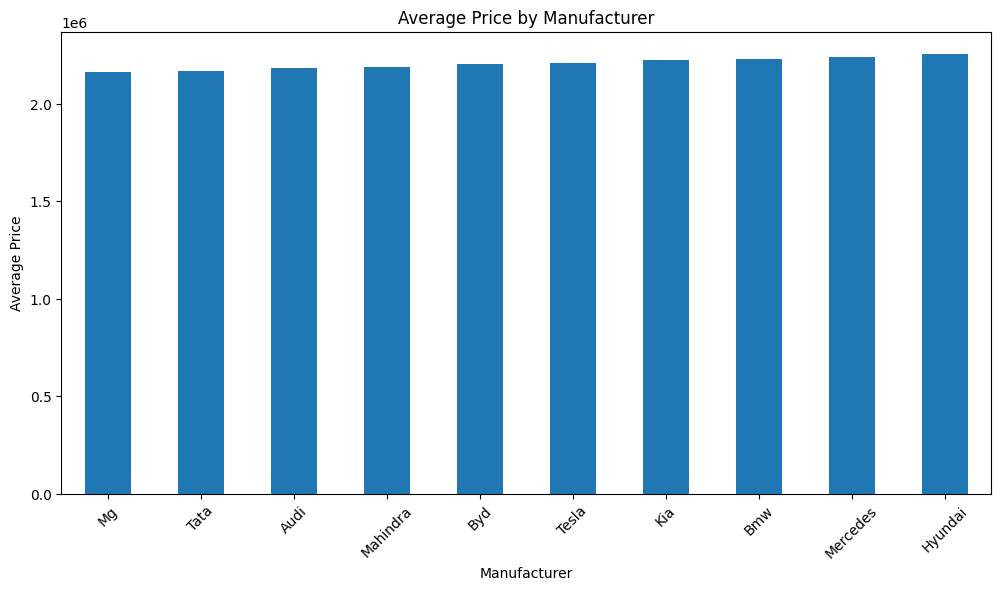

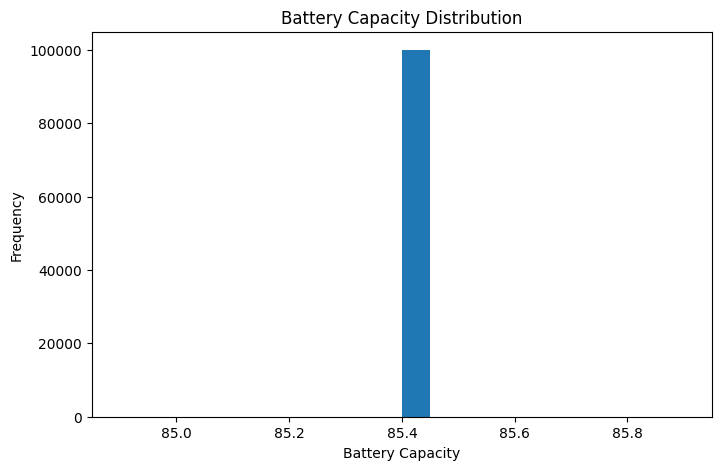

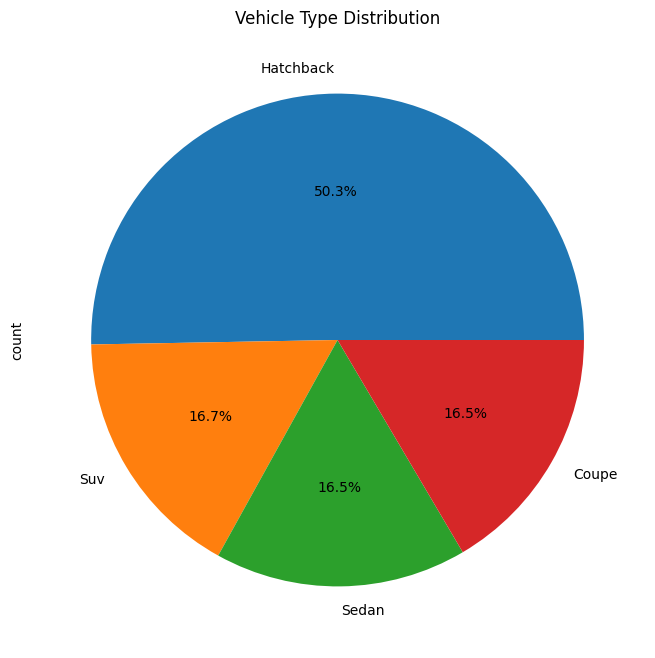

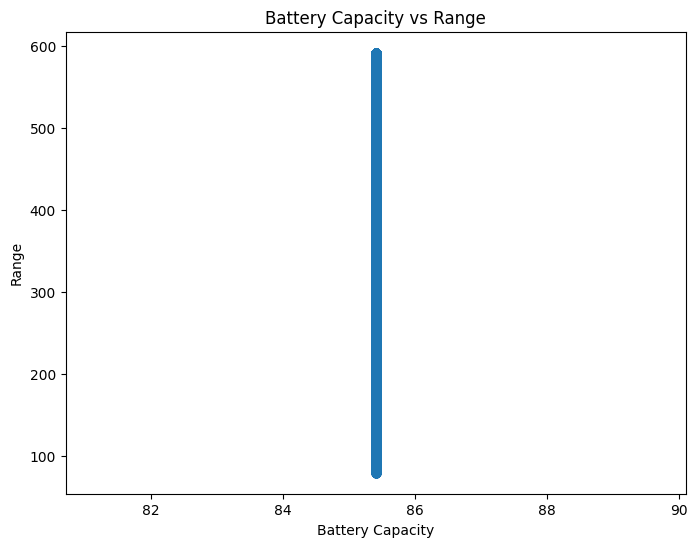

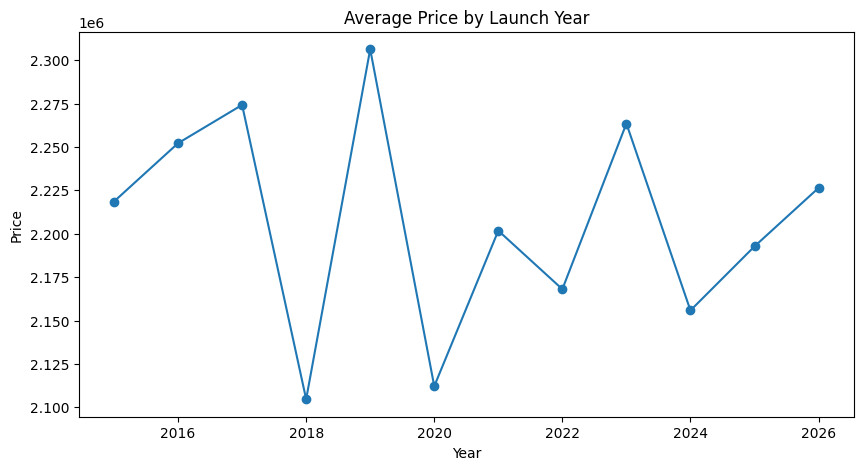

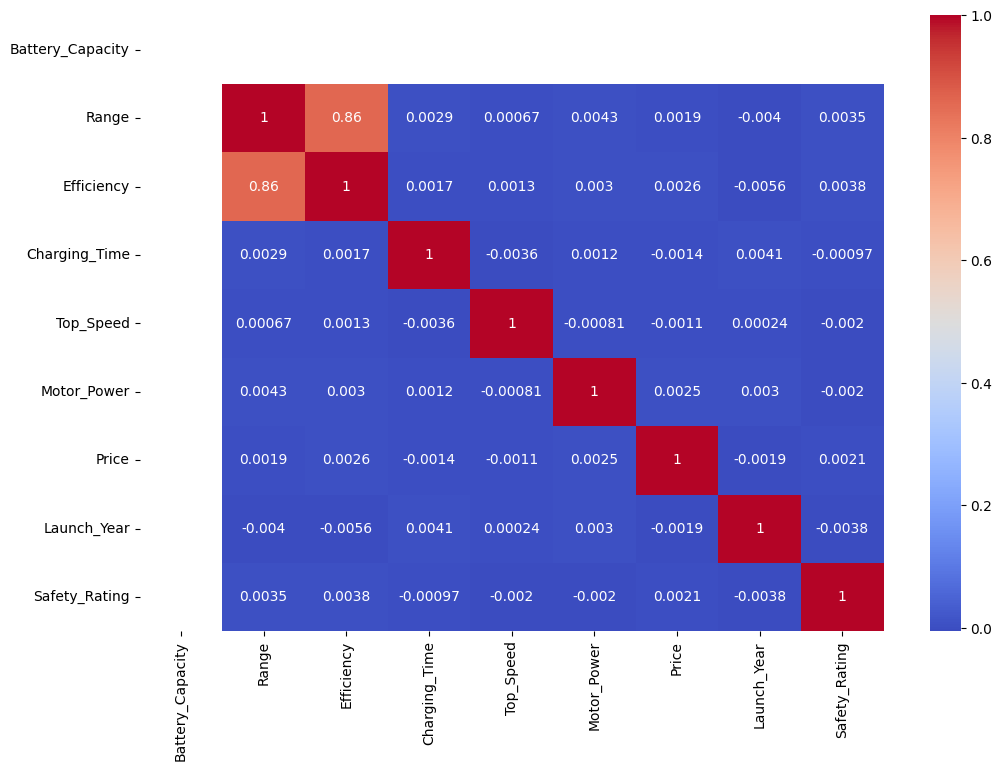

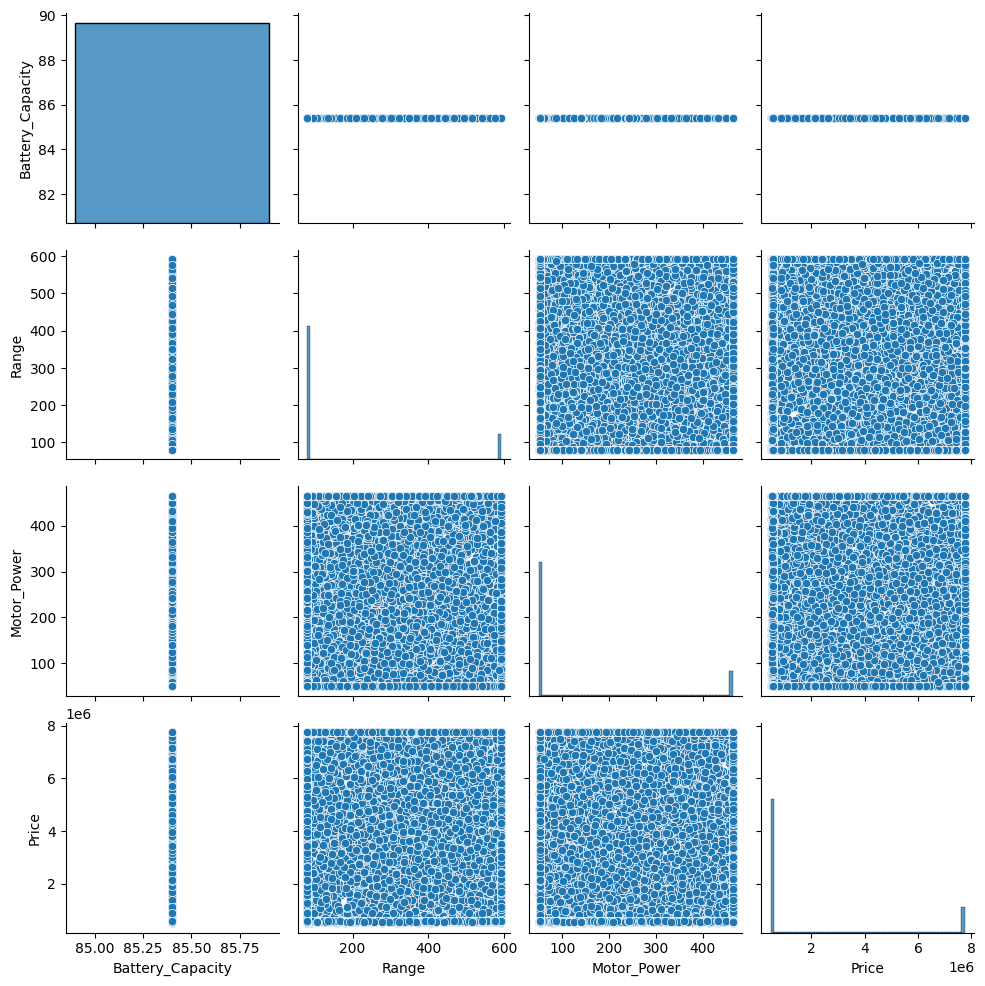

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Dataset Cleaned Successfully
Saved as EV_Cleaned_Dataset.csv


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
df = pd.read_csv("EV_Dirty_Dataset_100k.csv")
print("----------------INFORMATION-------------------")
print("----------------first 5 rows------------------")
print(df.head())
print("----------------info of dataset---------------")
print(df.info())
print("-----------------missing values----------------")
print(df.isnull())
print("---------------adding all missing values--------")
print(df.isnull().sum())
print(df.describe())


# ============================================
# 2. Remove Duplicate Rows
# ============================================

df.drop_duplicates(inplace=True)

print("\nAfter Removing Duplicates")
print(df.shape)

# ============================================
# 3. Replace Empty Strings with NaN
# ============================================

df.replace("", np.nan, inplace=True)
df.replace(" ", np.nan, inplace=True)

# ============================================
# 4. Fill Missing Values
# ============================================

# Numerical Columns
numerical_columns = [
    "Battery_Capacity",
    "Range",
    "Efficiency",
    "Charging_Time",
    "Top_Speed",
    "Motor_Power",
    "Price",
    "Launch_Year",
    "Safety_Rating"
]

for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical Columns
categorical_columns = [
    "Manufacturer",
    "Model",
    "Vehicle_Type",
    "Color",
    "Owner_Type"
]

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Vehicle ID
df["Vehicle_ID"].fillna("Unknown", inplace=True)

# ============================================
# 5. Remove Invalid Values
# ============================================

# Battery Capacity
df.loc[df["Battery_Capacity"] <= 0, "Battery_Capacity"] = np.nan

# Range
df.loc[df["Range"] < 0, "Range"] = np.nan

# Charging Time
df.loc[df["Charging_Time"] <= 0, "Charging_Time"] = np.nan

# Top Speed
df.loc[df["Top_Speed"] < 50, "Top_Speed"] = np.nan
df.loc[df["Top_Speed"] > 350, "Top_Speed"] = np.nan

# Motor Power
df.loc[df["Motor_Power"] <= 0, "Motor_Power"] = np.nan

# Price
df.loc[df["Price"] <= 0, "Price"] = np.nan

# Launch Year
df.loc[df["Launch_Year"] < 2015, "Launch_Year"] = np.nan
df.loc[df["Launch_Year"] > 2026, "Launch_Year"] = np.nan

# Safety Rating
df.loc[df["Safety_Rating"] < 1, "Safety_Rating"] = np.nan
df.loc[df["Safety_Rating"] > 5, "Safety_Rating"] = np.nan

# ============================================
# 6. Fill Missing Values Again
# ============================================

for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)

# ============================================
# 7. Remove Extra Spaces
# ============================================

text_columns = [
    "Manufacturer",
    "Model",
    "Vehicle_Type",
    "Color",
    "Owner_Type"
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

# ============================================
# 8. Standardize Text
# ============================================

for col in text_columns:
    df[col] = df[col].str.title()

# ============================================
# 9. Remove Impossible Efficiency
# ============================================

df.loc[df["Efficiency"] <= 0, "Efficiency"] = np.nan
df["Efficiency"].fillna(
    df["Range"] / df["Battery_Capacity"],
    inplace=True
)

# ============================================
# 10. Recalculate Efficiency
# ============================================

df["Efficiency"] = (
    df["Range"] /
    df["Battery_Capacity"]
).round(2)

# ============================================
# 11. Create Efficiency Category
# ============================================

def classify(x):

    if x > 8:
        return "Excellent"

    elif x >= 6:
        return "Good"

    elif x >= 4:
        return "Average"

    else:
        return "Poor"

df["Efficiency_Category"] = df["Efficiency"].apply(classify)

# ============================================
# 12. Detect Outliers (IQR)
# ============================================

columns = [
    "Battery_Capacity",
    "Range",
    "Charging_Time",
    "Top_Speed",
    "Motor_Power",
    "Price"
]

for col in columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(
        df[col] < lower,
        lower,
        df[col]
    )

    df[col] = np.where(
        df[col] > upper,
        upper,
        df[col]
    )

# ============================================
# 13. Check Clean Dataset
# ============================================

print("\nRemaining Missing Values")
print(df.isnull().sum())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Info")
print(df.info())

# ============================================
# 14. Save Clean Dataset
# ============================================
plt.figure(figsize=(12,6))

df.groupby("Manufacturer")["Price"].mean().sort_values().plot(kind="bar")

plt.title("Average Price by Manufacturer")
plt.xlabel("Manufacturer")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.show()
plt.figure(figsize=(8,5))

plt.hist(df["Battery_Capacity"], bins=20)

plt.title("Battery Capacity Distribution")
plt.xlabel("Battery Capacity")
plt.ylabel("Frequency")

plt.show()
plt.figure(figsize=(8,8))

df["Vehicle_Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Vehicle Type Distribution")

plt.show()
plt.figure(figsize=(8,6))

plt.scatter(
    df["Battery_Capacity"],
    df["Range"]
)

plt.xlabel("Battery Capacity")

plt.ylabel("Range")

plt.title("Battery Capacity vs Range")

plt.show()
manufacturer = df.groupby("Launch_Year")["Price"].mean()

plt.figure(figsize=(10,5))

plt.plot(
    manufacturer.index,
    manufacturer.values,
    marker="o"
)

plt.title("Average Price by Launch Year")

plt.xlabel("Year")

plt.ylabel("Price")

plt.show()
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()
sns.pairplot(
    df[
        [
            "Battery_Capacity",
            "Range",
            "Motor_Power",
            "Price"
        ]
    ]
)

plt.show()

df.to_csv("EV_Cleaned_Dataset.csv", index=False)
from google.colab import files
files.download("EV_Cleaned_Dataset.csv")
print("\nDataset Cleaned Successfully")
print("Saved as EV_Cleaned_Dataset.csv")